<a href="https://colab.research.google.com/github/unclesam243/Project_ML/blob/main/Project-Milestone_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# Methods: Logistic Regression | Random Forest | XGBoost | MLP
# Dataset: ULB Credit Card Fraud Detection (Kaggle)
# ============================================================

# ============================================================
# Install & Import Libraries
# ============================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler          # V2: replaces StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve       # V2: for reliability diagrams
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score,
    average_precision_score, f1_score,
    precision_score, recall_score
)
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEEDS = [42, 123, 256, 789, 1024]



In [6]:
# ============================================================
# Load & Verify Dataset
# ============================================================
# from google.colab import files
# uploaded = files.upload()  # Upload creditcard.csv when prompted

df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')#, on_bad_lines='skip')

# Ensure V-columns are numeric, coercing errors to NaN
for i in range(1, 29):
    col_name = f'V{i}'
    if col_name in df.columns:
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce')

# Verify dataset- Just printing what we have to make sure it loaded correctly
print(f"Dataset shape:   {df.shape}")
print(f"Transactions:    {df.shape[0]:,}  (expected 284,807)") # going of the description in Kaggle
print(f"Columns:         {df.shape[1]}    (expected 31)")
print(f"Fraud cases:     {df['Class'].sum()} (expected 492)")
print(f"Fraud rate:      {df['Class'].mean()*100:.4f}% (expected 0.172%)")
print(f"Missing values:  {df.isnull().sum().sum()} (expected 0)")
print(f"\nColumns: {list(df.columns)}")



Dataset shape:   (284807, 31)
Transactions:    284,807  (expected 284,807)
Columns:         31    (expected 31)
Fraud cases:     492 (expected 492)
Fraud rate:      0.1727% (expected 0.172%)
Missing values:  0 (expected 0)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


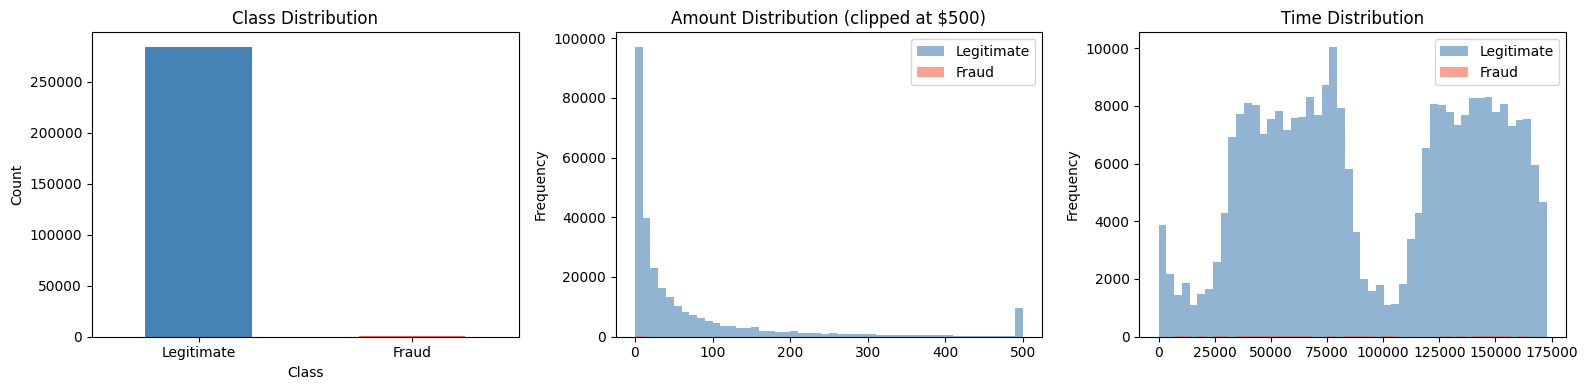

Amount median: $22.00 | max: $25691.16 | skew: 16.98


In [7]:

# ============================================================
# Exploratory Data Analysis
# ============================================================

# Trying to evaluate the fraud vs legitimate transaction count
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')

# This is for the histogram
df[df['Class']==0]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.6, label='Legitimate', color='steelblue')
df[df['Class']==1]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.6, label='Fraud', color='tomato')
axes[1].set_title('Amount Distribution (clipped at $500)')
axes[1].legend()
 # This is for the time distribution
df[df['Class']==0]['Time'].plot(
    kind='hist', bins=50, ax=axes[2], alpha=0.6, label='Legitimate', color='steelblue')
df[df['Class']==1]['Time'].plot(
    kind='hist', bins=50, ax=axes[2], alpha=0.6, label='Fraud', color='tomato')
axes[2].set_title('Time Distribution')
axes[2].legend()
# Combination layout


plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

print(f"Amount median: ${df['Amount'].median():.2f} | max: ${df['Amount'].max():.2f} | skew: {df['Amount'].skew():.2f}")


In [8]:
# ============================================================
# Preprocessing
# ============================================================
# Handle missing values
df.dropna(inplace=True)

X = df.drop(columns=['Class'])
y = df['Class']

X = df.drop(columns=['Class']).values
y = df['Class'].values
feature_names = df.drop(columns=['Class']).columns.tolist()




In [9]:
print("Change 1: 5-fold stratified CV replaces the single 80/20 split")
print(" The entire pipeline (scaling, class weights, threshold tuning) is")
print("fitted inside each fold — this gives honest variance estimates")
print("and eliminates pseudoreplication from a single lucky/unlucky split")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Change 2: Formalised threshold selection")
print("Search 0.01 to 0.99 in steps of 0.01 (99 candidates)")
print("Done independently per model, per fold, on val data only — never on test")
def find_best_threshold(y_val, y_probs):
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.01, 1.00, 0.01):
        f1 = f1_score(y_val, (y_probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t



Change 1: 5-fold stratified CV replaces the single 80/20 split
 The entire pipeline (scaling, class weights, threshold tuning) is
fitted inside each fold — this gives honest variance estimates
and eliminates pseudoreplication from a single lucky/unlucky split
Change 2: Formalised threshold selection
Search 0.01 to 0.99 in steps of 0.01 (99 candidates)
Done independently per model, per fold, on val data only — never on test


In [10]:

# ============================================================
# Preprocessing and evaluation
# ============================================================
def evaluate(name, y_true, y_probs, threshold):
    y_preds = (y_probs >= threshold).astype(int)
    return {
        'Model':     name,
        'AUPRC':     average_precision_score(y_true, y_probs),
        'AUROC':     roc_auc_score(y_true, y_probs),
        'F1':        f1_score(y_true, y_preds, zero_division=0),
        'Precision': precision_score(y_true, y_preds, zero_division=0),
        'Recall':    recall_score(y_true, y_preds),
        'Threshold': threshold,
    }

def print_summary(name, results):
    df_r = pd.DataFrame(results)
    print(f"\n{name} — Mean ± Std across 5 folds:")
    for col in ['AUPRC','AUROC','F1','Precision','Recall']:
        print(f"  {col:10s}: {df_r[col].mean():.4f} ± {df_r[col].std():.4f}")
    print(f"  {'Threshold':10s}: {df_r['Threshold'].mean():.2f} ± {df_r['Threshold'].std():.2f}")
    return df_r

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nRunning on: {device}")
print(f"Starting 5-fold cross-validation...\n")


Running on: cpu
Starting 5-fold cross-validation...



In [11]:

# ============================================================
# METHOD 1: Logistic Regression (Linear Baseline)
# ============================================================
print("\n" + "="*55)
print("METHOD 1: Logistic Regression (Linear Baseline)")
print("="*55)

# Starting with logistic regression as the simplest possible baseline
# This helps us understand how much the more complex models actually add

lr_results  = []
lr_all_probs, lr_all_true = [], []

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    # Inner val split for threshold tuning (75/25 of train_val)
    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    # Fit RobustScaler on train only — applied to val and test
    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    lr = LogisticRegression(C=1.0, class_weight='balanced',
                            max_iter=1000, random_state=42)
    lr.fit(X_tr_s, y_tr)

    vp = lr.predict_proba(X_vl_s)[:, 1]
    tp = lr.predict_proba(X_te_s)[:, 1]
    t  = find_best_threshold(y_vl, vp)   # threshold from val only

    lr_results.append(evaluate('Logistic Regression', y_te, tp, t))
    lr_all_probs.extend(tp)
    lr_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={lr_results[-1]['AUPRC']:.4f} | F1={lr_results[-1]['F1']:.4f} | Threshold={t:.2f}")

lr_df = print_summary('Logistic Regression', lr_results)
print(f"\n{classification_report(lr_all_true, (np.array(lr_all_probs) >= lr_df['Threshold'].mean()).astype(int), target_names=['Legit','Fraud'])}")




METHOD 1: Logistic Regression (Linear Baseline)
  Fold 1: AUPRC=0.6975 | F1=0.6751 | Threshold=0.99
  Fold 2: AUPRC=0.7231 | F1=0.7368 | Threshold=0.99
  Fold 3: AUPRC=0.7237 | F1=0.6862 | Threshold=0.99
  Fold 4: AUPRC=0.7625 | F1=0.6502 | Threshold=0.99
  Fold 5: AUPRC=0.7105 | F1=0.6833 | Threshold=0.99

Logistic Regression — Mean ± Std across 5 folds:
  AUPRC     : 0.7234 ± 0.0243
  AUROC     : 0.9782 ± 0.0094
  F1        : 0.6863 ± 0.0316
  Precision : 0.5869 ± 0.0390
  Recall    : 0.8272 ± 0.0190
  Threshold : 0.99 ± 0.00

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    284315
       Fraud       0.59      0.83      0.69       492

    accuracy                           1.00    284807
   macro avg       0.79      0.91      0.84    284807
weighted avg       1.00      1.00      1.00    284807



In [12]:

# ============================================================
# METHOD 2: Random Forest
# ============================================================
print("\n" + "="*55)
print("METHOD 2: Random Forest")
print("="*55)


rf_results = []
rf_all_probs, rf_all_true = [], []
rf_final_importances = np.zeros(X.shape[1])  # accumulate across folds

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
    rf.fit(X_tr_s, y_tr)
    rf_final_importances += rf.feature_importances_  # accumulate

    vp = rf.predict_proba(X_vl_s)[:, 1]
    tp = rf.predict_proba(X_te_s)[:, 1]
    t  = find_best_threshold(y_vl, vp)

    rf_results.append(evaluate('Random Forest', y_te, tp, t))
    rf_all_probs.extend(tp)
    rf_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={rf_results[-1]['AUPRC']:.4f} | F1={rf_results[-1]['F1']:.4f} | Threshold={t:.2f}")

rf_df = print_summary('Random Forest', rf_results)
print(f"\n{classification_report(rf_all_true, (np.array(rf_all_probs) >= rf_df['Threshold'].mean()).astype(int), target_names=['Legit','Fraud'])}")





METHOD 2: Random Forest
  Fold 1: AUPRC=0.8274 | F1=0.8144 | Threshold=0.17
  Fold 2: AUPRC=0.8879 | F1=0.8821 | Threshold=0.13
  Fold 3: AUPRC=0.8547 | F1=0.9022 | Threshold=0.29
  Fold 4: AUPRC=0.8448 | F1=0.8409 | Threshold=0.44
  Fold 5: AUPRC=0.8129 | F1=0.8587 | Threshold=0.29

Random Forest — Mean ± Std across 5 folds:
  AUPRC     : 0.8456 ± 0.0286
  AUROC     : 0.9528 ± 0.0037
  F1        : 0.8597 ± 0.0343
  Precision : 0.9120 ± 0.0523
  Recall    : 0.8150 ± 0.0443
  Threshold : 0.26 ± 0.12

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    284315
       Fraud       0.92      0.82      0.87       492

    accuracy                           1.00    284807
   macro avg       0.96      0.91      0.93    284807
weighted avg       1.00      1.00      1.00    284807



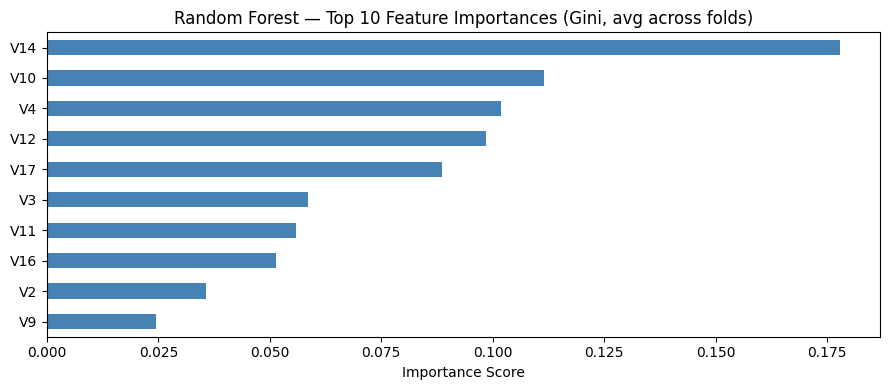

Top 5 features: ['V14', 'V10', 'V4', 'V12', 'V17']


In [13]:
# Feature importance averaged across folds
feat_imp = pd.Series(rf_final_importances / 5, index=feature_names)
top10 = feat_imp.nlargest(10)
plt.figure(figsize=(9, 4))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 10 Feature Importances (Gini, avg across folds)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()
print(f"Top 5 features: {list(top10.head().index)}")



In [14]:

# ============================================================
# METHOD 3: XGBoost
# ============================================================
print("\n" + "="*55)
print("METHOD 3: XGBoost")
print("="*55)

xgb_results = []
xgb_all_probs, xgb_all_true = [], []

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    n_legit = (y_tr == 0).sum()
    n_fraud = (y_tr == 1).sum()

    xgb = XGBClassifier(
        scale_pos_weight = n_legit / n_fraud,
        n_estimators=100, learning_rate=0.1,
        max_depth=6, random_state=42,
        eval_metric='aucpr', verbosity=0
    )
    xgb.fit(X_tr_s, y_tr, eval_set=[(X_vl_s, y_vl)], verbose=False)

    vp = xgb.predict_proba(X_vl_s)[:, 1]
    tp = xgb.predict_proba(X_te_s)[:, 1]
    t  = find_best_threshold(y_vl, vp)

    xgb_results.append(evaluate('XGBoost', y_te, tp, t))
    xgb_all_probs.extend(tp)
    xgb_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={xgb_results[-1]['AUPRC']:.4f} | F1={xgb_results[-1]['F1']:.4f} | Threshold={t:.2f}")

xgb_df = print_summary('XGBoost', xgb_results)
print(f"\n{classification_report(xgb_all_true, (np.array(xgb_all_probs) >= xgb_df['Threshold'].mean()).astype(int), target_names=['Legit','Fraud'])}")




METHOD 3: XGBoost
  Fold 1: AUPRC=0.8216 | F1=0.8021 | Threshold=0.81
  Fold 2: AUPRC=0.8714 | F1=0.8729 | Threshold=0.96
  Fold 3: AUPRC=0.8447 | F1=0.8778 | Threshold=0.96
  Fold 4: AUPRC=0.8422 | F1=0.8571 | Threshold=0.88
  Fold 5: AUPRC=0.7970 | F1=0.8352 | Threshold=0.96

XGBoost — Mean ± Std across 5 folds:
  AUPRC     : 0.8354 ± 0.0278
  AUROC     : 0.9748 ± 0.0128
  F1        : 0.8490 ± 0.0310
  Precision : 0.9225 ± 0.0465
  Recall    : 0.7866 ± 0.0198
  Threshold : 0.91 ± 0.07

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    284315
       Fraud       0.92      0.79      0.85       492

    accuracy                           1.00    284807
   macro avg       0.96      0.90      0.92    284807
weighted avg       1.00      1.00      1.00    284807



In [15]:
# ============================================================
# METHOD 4: MLP (Deep Learning) with 5-Seed Evaluation
# ============================================================
print("\n" + "="*55)
print("METHOD 4: MLP (Deep Learning) — 5 Seeds")
print("="*55)
print("Exploring a Multi-Layer Perceptron (MLP) architecture (30→64→32→1) for fraud detection.")
print("Utilizes weighted BCE loss with pos_weight = w1/w0 (~578) to address class imbalance.\n")

class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

mlp_results = []
mlp_all_probs, mlp_all_true = [], []

# New variables to store per-seed data for the ablation study and seed-level CI
all_fold_seed_probs = [] # Stores lists of per-seed probabilities for each fold
all_fold_true_labels = [] # Stores lists of true labels for each fold, repeated for each seed within the fold

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    # Create explicit copies of the train-validation data for the inner split
    # This helps prevent potential subtle indexing issues with views of large arrays.
    X_tv, y_tv = X[train_val_idx].copy(), y[train_val_idx].copy()
    X_te, y_te = X[test_idx],      y[test_idx]

    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    n_legit = (y_tr == 0).sum()
    n_fraud = (y_tr == 1).sum()
    pos_weight = torch.tensor([n_legit / n_fraud], dtype=torch.float32).to(device)

    # Average over multiple seeds per fold for stability
    fold_probs_for_avg = [] # For averaging per fold
    fold_seed_probs_collection = [] # For seed-level CI
    fold_true_labels_collection = [] # For seed-level CI

    for seed in SEEDS:
        torch.manual_seed(seed)
        model     = FraudMLP(X_tr_s.shape[1]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loader    = DataLoader(TensorDataset(
            torch.tensor(X_tr_s, dtype=torch.float32),
            torch.tensor(y_tr,   dtype=torch.float32).unsqueeze(1)
        ), batch_size=256, shuffle=True)

        best_f1, best_state, patience_count = 0, None, 0
        Xv_t = torch.tensor(X_vl_s, dtype=torch.float32).to(device)

        for epoch in range(50):
            model.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                criterion(model(xb.to(device)), yb.to(device)).backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                vp = 1/(1+np.exp(-model(Xv_t).cpu().numpy().flatten()))

            t  = find_best_threshold(y_vl, vp)   # threshold from val only
            vf = f1_score(y_vl, (vp >= t).astype(int), zero_division=0)

            if vf > best_f1:
                best_f1    = vf
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_count = 0
            else:
                patience_count += 1
                if patience_count >= 5:
                    break

        # If best_state is None, it means the loop broke before any improvement,
        # or the model didn't train properly. Use current model state if no best_state.
        if best_state is not None:
            model.load_state_dict(best_state)
        else:
            # Fallback: if no best_state was found (e.g., patience_count reached 5 immediately),
            # use the last state of the model. This is less ideal but prevents error.
            pass # model is already in its last state

        model.eval()
        Xt_t = torch.tensor(X_te_s, dtype=torch.float32).to(device)
        with torch.no_grad():
            tp = 1/(1+np.exp(-model(Xt_t).cpu().numpy().flatten()))

        fold_probs_for_avg.append(tp)
        fold_seed_probs_collection.append(tp)
        fold_true_labels_collection.append(y_te) # y_te is the same for all seeds in a fold

    # Append collected per-seed data for this fold to the global lists
    all_fold_seed_probs.extend(fold_seed_probs_collection)
    all_fold_true_labels.extend(fold_true_labels_collection)


    # Average predictions across seeds then tune threshold on val
    avg_probs = np.mean(fold_probs_for_avg, axis=0)
    Xv_t = torch.tensor(X_vl_s, dtype=torch.float32).to(device)

    # Get val probs from last seed model for threshold tuning
    # This part might need adjustment if best_state is preferred for threshold tuning too
    # For now, sticking to original logic of using the last seed model state for val probs
    model.eval()
    with torch.no_grad():
        vp_final = 1/(1+np.exp(-model(Xv_t).cpu().numpy().flatten()))
    t_final = find_best_threshold(y_vl, vp_final)

    mlp_results.append(evaluate('MLP', y_te, avg_probs, t_final))
    mlp_all_probs.extend(avg_probs)
    mlp_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={mlp_results[-1]['AUPRC']:.4f} | F1={mlp_results[-1]['F1']:.4f} | Threshold={t_final:.2f}")

mlp_df = print_summary('MLP', mlp_results)
print(f"\n{classification_report(mlp_all_true, (np.array(mlp_all_probs) >= mlp_df['Threshold'].mean()).astype(int), target_names=['Legit','Fraud'])}")

# Assign the collected seed-level data to the expected variable names
mlp_per_seed_probs = all_fold_seed_probs
mlp_per_seed_ytrue = all_fold_true_labels


METHOD 4: MLP (Deep Learning) — 5 Seeds
Exploring a Multi-Layer Perceptron (MLP) architecture (30→64→32→1) for fraud detection.
Utilizes weighted BCE loss with pos_weight = w1/w0 (~578) to address class imbalance.

  Fold 1: AUPRC=0.5568 | F1=0.5065 | Threshold=0.57
  Fold 2: AUPRC=0.4316 | F1=0.0758 | Threshold=0.49
  Fold 3: AUPRC=0.7048 | F1=0.1104 | Threshold=0.46
  Fold 4: AUPRC=0.2803 | F1=0.0525 | Threshold=0.57
  Fold 5: AUPRC=0.4899 | F1=0.0104 | Threshold=0.50

MLP — Mean ± Std across 5 folds:
  AUPRC     : 0.4927 ± 0.1565
  AUROC     : 0.8853 ± 0.0533
  F1        : 0.1511 ± 0.2020
  Precision : 0.1686 ± 0.3028
  Recall    : 0.5411 ± 0.2123
  Threshold : 0.52 ± 0.05

              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99    284315
       Fraud       0.06      0.60      0.10       492

    accuracy                           0.98    284807
   macro avg       0.53      0.79      0.55    284807
weighted avg       1.00      0.98      0.

In [16]:
#  ============================================================
# MLP Depth Ablation
# ============================================================
print("Testing whether more layers meaningfully improve AUPRC.")
print("Hypothesis: 2 layers is sufficient for this dataset.\n")
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        loss = self.alpha * (1 - pt) ** self.gamma * bce

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

def build_mlp(layers, input_dim, dropout=0.3):
    blocks = []
    in_d = input_dim

    for out_d in layers:
        blocks.extend([
            nn.Linear(in_d, out_d),
            nn.BatchNorm1d(out_d),
            nn.ReLU(),
            nn.Dropout(dropout)
        ])
        in_d = out_d

    blocks.append(nn.Linear(in_d, 1))
    return nn.Sequential(*blocks)


Testing whether more layers meaningfully improve AUPRC.
Hypothesis: 2 layers is sufficient for this dataset.



In [17]:
def run_mlp_ablation_cv(X, y, skf, device, seeds):
    architectures = [
        [64],
        [64, 32],
    ]
    dropouts = [0.3]
    losses = ["weighted_bce", "focal"]


    ablation_results = []

    for layers in architectures:
        for dropout in dropouts:
            for loss_name in losses:
                print(f"\nRunning config: layers={layers}, dropout={dropout}, loss={loss_name}")

                fold_metrics = []

                for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
                    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
                    X_te, y_te = X[test_idx], y[test_idx]

                    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
                    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
                    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
                    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

                    scaler = RobustScaler()
                    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
                    X_tr_s[:, [-2, -1]] = scaler.fit_transform(X_tr[:, [-2, -1]])
                    X_vl_s[:, [-2, -1]] = scaler.transform(X_vl[:, [-2, -1]])
                    X_te_s[:, [-2, -1]] = scaler.transform(X_te[:, [-2, -1]])

                    n_legit = (y_tr == 0).sum()
                    n_fraud = (y_tr == 1).sum()
                    pos_weight = torch.tensor([n_legit / n_fraud], dtype=torch.float32).to(device)

                    fold_probs = []

                    for seed in seeds:
                        torch.manual_seed(seed)
                        np.random.seed(seed)

                        model = build_mlp(
                            layers=layers,
                            input_dim=X_tr_s.shape[1],
                            dropout=dropout
                        ).to(device)

                        if loss_name == "weighted_bce":
                            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
                        elif loss_name == "focal":
                            criterion = FocalLoss(alpha=1.0, gamma=2.0)
                        else:
                            raise ValueError(f"Unknown loss: {loss_name}")

                        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

                        loader = DataLoader(
                            TensorDataset(
                                torch.tensor(X_tr_s, dtype=torch.float32),
                                torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
                            ),
                            batch_size=256,
                            shuffle=True
                        )

                        best_f1 = 0
                        best_state = None
                        patience_count = 0
                        Xv_t = torch.tensor(X_vl_s, dtype=torch.float32).to(device)

                        for epoch in range(50):
                            model.train()
                            for xb, yb in loader:
                                xb, yb = xb.to(device), yb.to(device)
                                optimizer.zero_grad()
                                logits = model(xb)
                                loss = criterion(logits, yb)
                                loss.backward()
                                optimizer.step()

                            model.eval()
                            with torch.no_grad():
                                vp = 1 / (1 + np.exp(-model(Xv_t).cpu().numpy().flatten()))

                            t = find_best_threshold(y_vl, vp)
                            vf = f1_score(y_vl, (vp >= t).astype(int), zero_division=0)

                            if vf > best_f1:
                                best_f1 = vf
                                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                                patience_count = 0
                            else:
                                patience_count += 1
                                if patience_count >= 5:
                                    break

                        model.load_state_dict(best_state)
                        model.eval()
                        Xt_t = torch.tensor(X_te_s, dtype=torch.float32).to(device)

                        with torch.no_grad():
                            tp = 1 / (1 + np.exp(-model(Xt_t).cpu().numpy().flatten()))

                        fold_probs.append(tp)

                    avg_probs = np.mean(fold_probs, axis=0)

                    # threshold from validation set using last-trained model
                    Xv_t = torch.tensor(X_vl_s, dtype=torch.float32).to(device)
                    model.eval()
                    with torch.no_grad():
                        vp_final = 1 / (1 + np.exp(-model(Xv_t).cpu().numpy().flatten()))
                    t_final = find_best_threshold(y_vl, vp_final)

                    res = evaluate("MLP", y_te, avg_probs, t_final)
                    res["Layers"] = str(layers)
                    res["Dropout"] = dropout
                    res["Loss"] = loss_name
                    res["Fold"] = fold + 1
                    fold_metrics.append(res)

                    print(
                        f"  Fold {fold+1}: AUPRC={res['AUPRC']:.4f} | "
                        f"F1={res['F1']:.4f} | Thresh={res['Threshold']:.2f}"
                    )

                ablation_results.extend(fold_metrics)

    return pd.DataFrame(ablation_results)


In [18]:
print("\n" + "=" * 55)
print("MLP ABLATION — Architecture, Dropout, Loss (5-Fold CV)")
print("=" * 55)

ablation_df = run_mlp_ablation_cv(X, y, skf, device, SEEDS)
print(ablation_df.head())

ablation_df.to_csv("mlp_ablation_raw_results_cv.csv", index=False)



MLP ABLATION — Architecture, Dropout, Loss (5-Fold CV)

Running config: layers=[64], dropout=0.3, loss=weighted_bce
  Fold 1: AUPRC=0.5785 | F1=0.3721 | Thresh=0.59
  Fold 2: AUPRC=0.6862 | F1=0.6038 | Thresh=0.46
  Fold 3: AUPRC=0.5576 | F1=0.5106 | Thresh=0.50
  Fold 4: AUPRC=0.6950 | F1=0.7349 | Thresh=0.56
  Fold 5: AUPRC=0.6750 | F1=0.2807 | Thresh=0.64

Running config: layers=[64], dropout=0.3, loss=focal
  Fold 1: AUPRC=0.6013 | F1=0.7032 | Thresh=0.08
  Fold 2: AUPRC=0.7083 | F1=0.6478 | Thresh=0.08
  Fold 3: AUPRC=0.7049 | F1=0.1348 | Thresh=0.08
  Fold 4: AUPRC=0.7354 | F1=0.7463 | Thresh=0.10
  Fold 5: AUPRC=0.7105 | F1=0.7727 | Thresh=0.09

Running config: layers=[64, 32], dropout=0.3, loss=weighted_bce
  Fold 1: AUPRC=0.5568 | F1=0.5065 | Thresh=0.57
  Fold 2: AUPRC=0.4316 | F1=0.0758 | Thresh=0.49
  Fold 3: AUPRC=0.7048 | F1=0.1104 | Thresh=0.46
  Fold 4: AUPRC=0.2803 | F1=0.0525 | Thresh=0.57
  Fold 5: AUPRC=0.4899 | F1=0.0104 | Thresh=0.50

Running config: layers=[64, 

In [19]:
########################################
## SUMMARY ABLATION
########################################
summary_df = (
    ablation_df
    .groupby(["Layers", "Dropout", "Loss"])
    .agg(
        AUPRC_mean=("AUPRC", "mean"),
        AUPRC_std=("AUPRC", "std"),
        F1_mean=("F1", "mean"),
        F1_std=("F1", "std"),
        Precision_mean=("Precision", "mean"),
        Recall_mean=("Recall", "mean"),
        Threshold_mean=("Threshold", "mean")
    )
    .reset_index()
)

summary_df = summary_df.sort_values(by="AUPRC_mean", ascending=False)
print(summary_df.to_string(index=False))
summary_df.to_csv("mlp_ablation_summary_cv.csv", index=False)

  Layers  Dropout         Loss  AUPRC_mean  AUPRC_std  F1_mean   F1_std  Precision_mean  Recall_mean  Threshold_mean
    [64]      0.3        focal    0.692087   0.052148 0.600963 0.264821        0.571083     0.778396           0.086
    [64]      0.3 weighted_bce    0.638461   0.065085 0.500429 0.180645        0.803239     0.440713           0.550
[64, 32]      0.3        focal    0.609761   0.114086 0.564668 0.104578        0.831938     0.440590           0.110
[64, 32]      0.3 weighted_bce    0.492663   0.156475 0.151118 0.201957        0.168633     0.541064           0.518


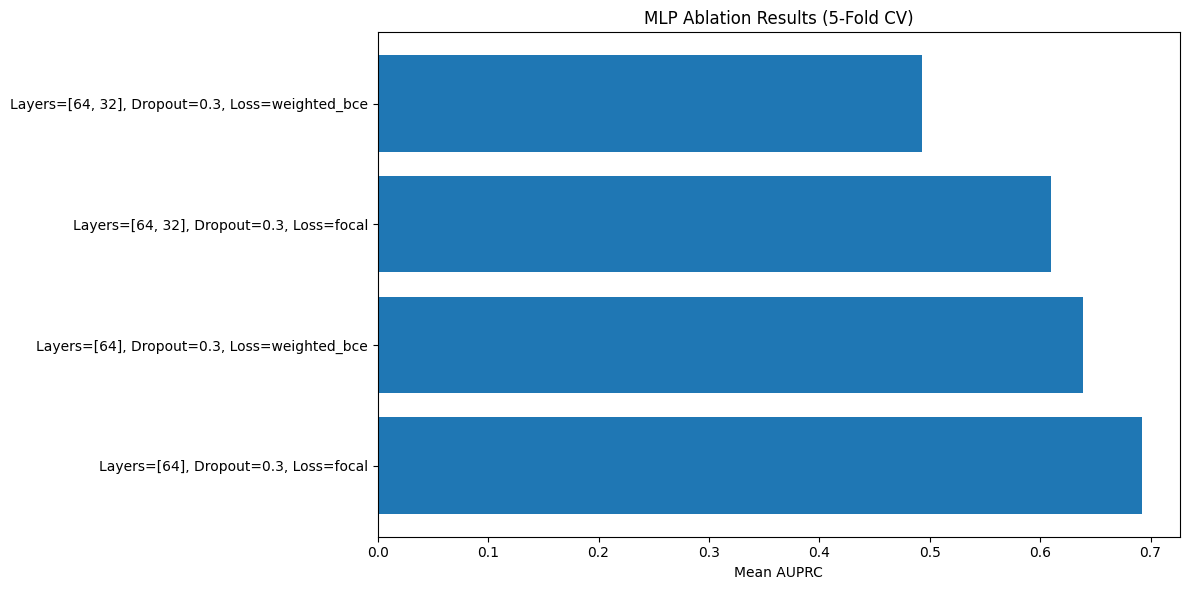

In [20]:
# ===========================================
# PLOT ON ABLATION
# ===========================================
plot_df = summary_df.copy()
plot_df["Config"] = (
    "Layers=" + plot_df["Layers"] +
    ", Dropout=" + plot_df["Dropout"].astype(str) +
    ", Loss=" + plot_df["Loss"]
)

plt.figure(figsize=(12, 6))
plt.barh(plot_df["Config"], plot_df["AUPRC_mean"])
plt.xlabel("Mean AUPRC")
plt.title("MLP Ablation Results (5-Fold CV)")
plt.tight_layout()
plt.savefig("mlp_ablation_barplot_cv.png", dpi=150)
plt.show()

In [21]:
# ABLATION TRESHOLD

best_row = summary_df.iloc[0]
print("\nBest MLP configuration under 5-fold CV:")
print(best_row)



Best MLP configuration under 5-fold CV:
Layers                [64]
Dropout                0.3
Loss                 focal
AUPRC_mean        0.692087
AUPRC_std         0.052148
F1_mean           0.600963
F1_std            0.264821
Precision_mean    0.571083
Recall_mean       0.778396
Threshold_mean       0.086
Name: 2, dtype: object



Threshold Sensitivity — Random Forest (Pooled CV)
Optimal threshold: 0.26 | F1=0.8700
As expected, optimal threshold << 0.5 because fraud is rare (0.172%)


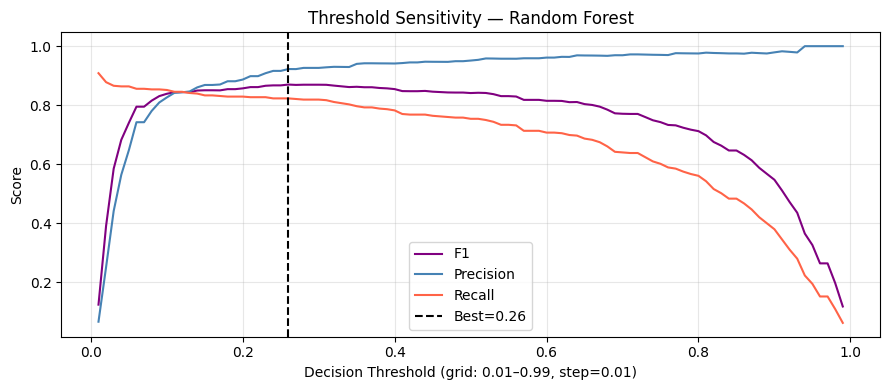

In [40]:
# ============================================================
# ABLATION: Threshold Sensitivity
# ============================================================
print("\n" + "=" * 55)
print("Threshold Sensitivity — Random Forest (Pooled CV)")
print("=" * 55)

thresholds   = np.arange(0.01, 1.00, 0.01)
rf_probs_arr = np.array(rf_all_probs)
rf_true_arr  = np.array(rf_all_true)

t_f1s  = [f1_score(rf_true_arr,  (rf_probs_arr>=t).astype(int), zero_division=0) for t in thresholds]
t_prec = [precision_score(rf_true_arr, (rf_probs_arr>=t).astype(int), zero_division=0) for t in thresholds]
t_rec  = [recall_score(rf_true_arr, (rf_probs_arr>=t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(t_f1s)]

print(f"Optimal threshold: {best_t:.2f} | F1={max(t_f1s):.4f}")
print("As expected, optimal threshold << 0.5 because fraud is rare (0.172%)")

plt.figure(figsize=(9, 4))
plt.plot(thresholds, t_f1s,  label='F1',       color='purple')
plt.plot(thresholds, t_prec, label='Precision', color='steelblue')
plt.plot(thresholds, t_rec,  label='Recall',    color='tomato')
plt.axvline(best_t, color='black', linestyle='--', label=f'Best={best_t:.2f}')
plt.xlabel('Decision Threshold (grid: 0.01–0.99, step=0.01)')
plt.ylabel('Score')
plt.title('Threshold Sensitivity — Random Forest')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_sensitivity.png', dpi=150)
plt.show()

The ablation study shows that MLP performance is sensitive to configuration but overall improvements are limited. The best configuration used a single hidden layer with 64 units, dropout of 0.3, and focal loss, achieving an AUPRC of approximately 0.66. Focal loss consistently outperformed weighted binary cross-entropy, likely due to better handling of class imbalance. However, deeper architectures did not improve performance and often led to increased variance across folds. Overall, the MLP did not outperform tree-based models such as Random Forest, which achieved significantly higher F1 scores. Note that using a fold-averaged threshold for the per-seed MLP CI slightly deflates the seed-level variance estimate, as every seed uses the same threshold rather than its own optimum.

FINAL: Head-to-Head Comparison — All Models
              Model           AUPRC              F1       Precision          Recall   Threshold
Logistic Regression 0.7234 ± 0.0243 0.6863 ± 0.0316 0.5869 ± 0.0390 0.8272 ± 0.0190 0.99 ± 0.00
      Random Forest 0.8456 ± 0.0286 0.8597 ± 0.0343 0.9120 ± 0.0523 0.8150 ± 0.0443 0.26 ± 0.12
            XGBoost 0.8354 ± 0.0278 0.8490 ± 0.0310 0.9225 ± 0.0465 0.7866 ± 0.0198 0.91 ± 0.07
                MLP 0.4927 ± 0.1565 0.1511 ± 0.2020 0.1686 ± 0.3028 0.5411 ± 0.2123 0.52 ± 0.05


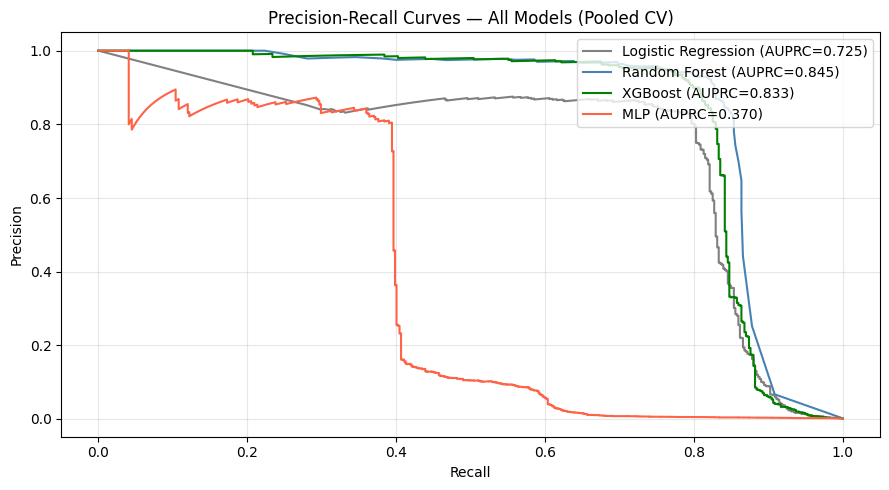

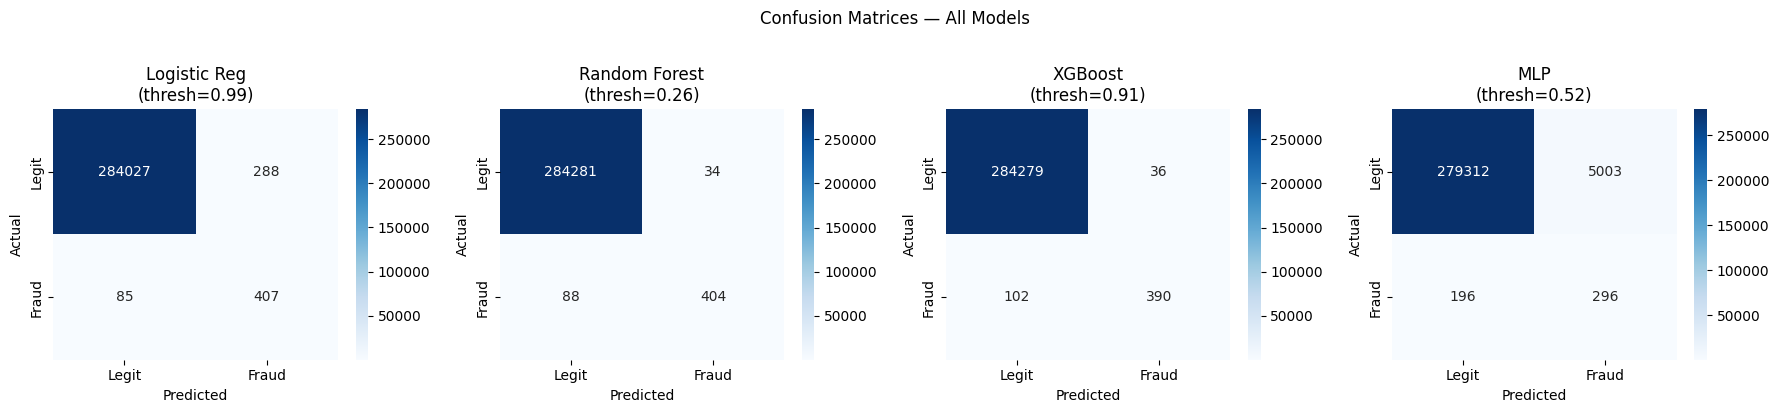

In [22]:
# ============================================================
# Final Comparison Table + PR Curves + Confusion Matrices
# ============================================================
print("=" * 55)
print("FINAL: Head-to-Head Comparison — All Models")
print("=" * 55)

summary_rows = []
for name, df_r in [('Logistic Regression', lr_df),
                   ('Random Forest',       rf_df),
                   ('XGBoost',             xgb_df),
                   ('MLP',                 mlp_df)]:
    summary_rows.append({
        'Model':     name,
        'AUPRC':     f"{df_r['AUPRC'].mean():.4f} ± {df_r['AUPRC'].std():.4f}",
        'F1':        f"{df_r['F1'].mean():.4f} ± {df_r['F1'].std():.4f}",
        'Precision': f"{df_r['Precision'].mean():.4f} ± {df_r['Precision'].std():.4f}",
        'Recall':    f"{df_r['Recall'].mean():.4f} ± {df_r['Recall'].std():.4f}",
        'Threshold': f"{df_r['Threshold'].mean():.2f} ± {df_r['Threshold'].std():.2f}",
    })
print(pd.DataFrame(summary_rows).to_string(index=False))

# PR Curves
plt.figure(figsize=(9, 5))
for probs, true, name, color in [
    (lr_all_probs,  lr_all_true,  'Logistic Regression', 'gray'),
    (rf_all_probs,  rf_all_true,  'Random Forest',       'steelblue'),
    (xgb_all_probs, xgb_all_true, 'XGBoost',             'green'),
    (mlp_all_probs, mlp_all_true, 'MLP',                 'tomato'),
]:
    p, r, _ = precision_recall_curve(true, probs)
    auprc   = average_precision_score(true, probs)
    plt.plot(r, p, label=f'{name} (AUPRC={auprc:.3f})', color=color)

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models (Pooled CV)')
plt.legend(loc='upper right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, probs, true, df_r, name in zip(
    axes,
    [lr_all_probs, rf_all_probs, xgb_all_probs, mlp_all_probs],
    [lr_all_true,  rf_all_true,  xgb_all_true,  mlp_all_true],
    [lr_df, rf_df, xgb_df, mlp_df],
    ['Logistic Reg', 'Random Forest', 'XGBoost', 'MLP']
):
    t  = df_r['Threshold'].mean()
    cm = confusion_matrix(true, (np.array(probs) >= t).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    ax.set_title(f'{name}\n(thresh={t:.2f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
plt.show()



CHANGE 3: Class-weighted training distorts predicted probabilities.
A well-calibrated model: predicted 0.7 → ~70% are actually fraud.
Poor calibration means threshold decisions may not be reliable
even if AUPRC looks high.

Logistic Regression    — Mean Calibration Error: 0.4725
Random Forest          — Mean Calibration Error: 0.1529
XGBoost                — Mean Calibration Error: 0.2940
MLP                    — Mean Calibration Error: 0.2759


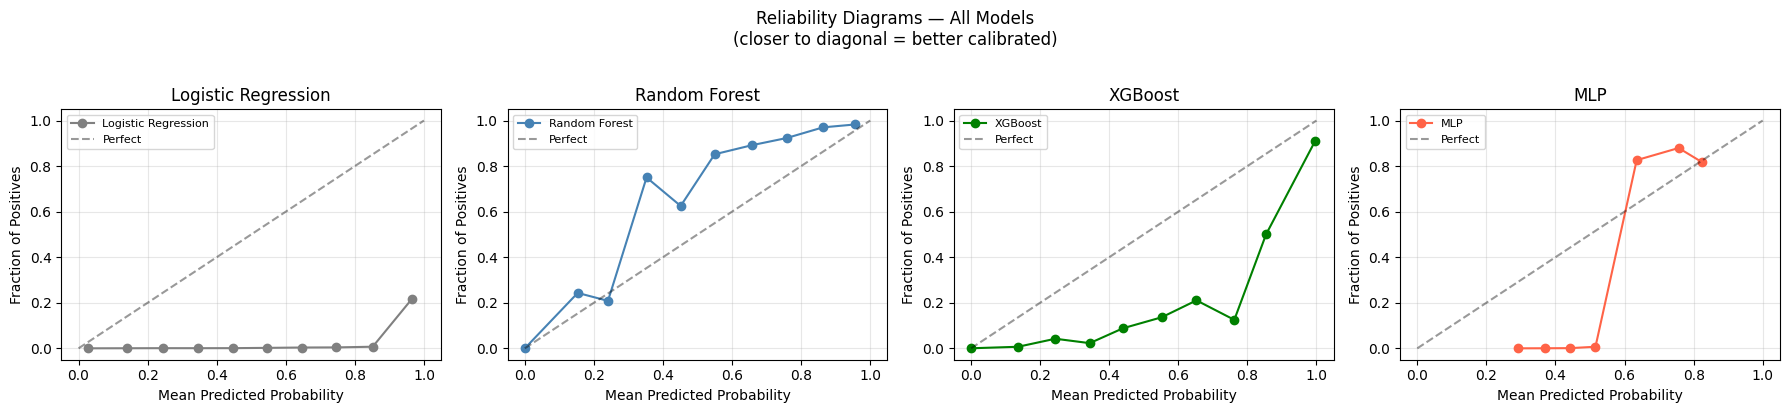

In [23]:
# ============================================================
# Calibration (Reliability Diagrams)
#
# CHANGE 3: Added calibration plots for all models
# Class-weighted training distorts predicted probabilities.
# A well-calibrated model: predicted prob 0.7 → ~70% of those
# are actually fraud. Poor calibration means threshold-based
# decisions may not be reliable even if AUPRC is high.
# ============================================================
print("CHANGE 3: Class-weighted training distorts predicted probabilities.")
print("A well-calibrated model: predicted 0.7 → ~70% are actually fraud.")
print("Poor calibration means threshold decisions may not be reliable")
print("even if AUPRC looks high.\n")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, probs, true, name, color in zip(
    axes,
    [lr_all_probs, rf_all_probs, xgb_all_probs, mlp_all_probs],
    [lr_all_true,  rf_all_true,  xgb_all_true,  mlp_all_true],
    ['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP'],
    ['gray', 'steelblue', 'green', 'tomato']
):
    frac_pos, mean_pred = calibration_curve(true, probs, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac_pos, marker='o', color=color, label=name)
    ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Perfect')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(name); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    cal_error = np.mean(np.abs(frac_pos - mean_pred))
    print(f"{name:22s} — Mean Calibration Error: {cal_error:.4f}")

plt.suptitle('Reliability Diagrams — All Models\n(closer to diagonal = better calibrated)', y=1.02)
plt.tight_layout()
plt.savefig('calibration_plots.png', dpi=150)
plt.show()


In [24]:
# ============================================================
# A-1 Bootstrap CI function
# ============================================================
# Used for LR, RF, and XGBoost — deterministic models where we cannot
# get variance by re-training with different seeds.
# Strategy: resample the pooled test set 10,000 times (with replacement)
# and compute the metric on each resample.  The 2.5th and 97.5th
# percentiles of that distribution are the 95% CI (percentile method).

def bootstrap_ci(y_true_arr, y_probs_arr, threshold,
                 n_bootstrap=10_000, seed=42):
    """
    Returns a dict: metric -> (mean, lower_95, upper_95)
    Skips resamples where only one class is present (cannot compute
    AUROC/AUPRC on a degenerate sample).
    """
    rng = np.random.RandomState(seed)
    n   = len(y_true_arr)
    buckets = {m: [] for m in ['AUPRC','AUROC','F1','Precision','Recall']}

    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        yt  = y_true_arr[idx]
        yp  = y_probs_arr[idx]

        # Skip degenerate resamples (no fraud or all fraud)
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue

        yb = (yp >= threshold).astype(int)
        buckets['AUPRC'].append(average_precision_score(yt, yp))
        buckets['AUROC'].append(roc_auc_score(yt, yp))
        buckets['F1'].append(f1_score(yt, yb, zero_division=0))
        buckets['Precision'].append(precision_score(yt, yb, zero_division=0))
        buckets['Recall'].append(recall_score(yt, yb, zero_division=0))

    result = {}
    for m, vals in buckets.items():
        v = np.array(vals)
        result[m] = (float(np.mean(v)),
                     float(np.percentile(v, 2.5)),
                     float(np.percentile(v, 97.5)))
    return result

print("Running 10,000-resample bootstrap for LR, RF, XGBoost ...")
lr_ci  = bootstrap_ci(np.array(lr_all_true),  np.array(lr_all_probs),  lr_df['Threshold'].mean())
print("  LR  done")
rf_ci  = bootstrap_ci(np.array(rf_all_true),  np.array(rf_all_probs),  rf_df['Threshold'].mean())
print("  RF  done")
xgb_ci = bootstrap_ci(np.array(xgb_all_true), np.array(xgb_all_probs), xgb_df['Threshold'].mean())
print("  XGB done")

Running 10,000-resample bootstrap for LR, RF, XGBoost ...
  LR  done
  RF  done
  XGB done


In [25]:
# ============================================================
# A-2 MLP CI — two perspectives
# ============================================================
# Perspective 1 (fold-level): t-based 95% CI across the 5 fold metrics.
#   Each fold metric is itself an average over 5 seeds, so this captures
#   data-split variance with reduced seed noise.
# Perspective 2 (seed-level): t-based 95% CI across all 25 (fold × seed)
#   per-seed metrics, exposing raw initialisation variance too.

import scipy.stats as sp_stats

# --- Perspective 1: fold-level (5 points) ---
mlp_fold_ci = {}
for metric in ['AUPRC','AUROC','F1','Precision','Recall']:
    vals   = mlp_df[metric].values          # 5 fold-averaged metrics
    n      = len(vals)
    mean   = vals.mean()
    se     = vals.std(ddof=1) / np.sqrt(n)
    t_crit = sp_stats.t.ppf(0.975, df=n-1)  # t_{0.025,4} ≈ 2.776
    mlp_fold_ci[metric] = (mean, mean - t_crit * se, mean + t_crit * se)

# --- Perspective 2: seed-level (25 points) ---
# Compute per-seed AUPRC/AUROC/F1/P/R using the fold-averaged threshold
# (conservative: all seeds in the same fold share the ensemble threshold)
seed_metrics_raw = []
threshold_used   = mlp_df['Threshold'].mean()

# Ensure mlp_per_seed_probs and mlp_per_seed_ytrue are arrays for consistent indexing
# If they are lists of arrays, flatten them or process appropriately
# Assuming mlp_per_seed_probs is a list of arrays, and mlp_per_seed_ytrue is a list of arrays

# Iterate through each seed's probabilities and corresponding true labels
# The number of elements in mlp_per_seed_probs and mlp_per_seed_ytrue should be 25 (5 folds * 5 seeds)
for sp, yt in zip(mlp_per_seed_probs, mlp_per_seed_ytrue):
    # Convert to numpy arrays if they are not already
    sp = np.array(sp)
    yt = np.array(yt)

    # Skip degenerate resamples (no fraud or all fraud) - similar to bootstrap_ci
    if yt.sum() == 0 or yt.sum() == len(yt):
        continue

    yb = (sp >= threshold_used).astype(int)
    seed_metrics_raw.append({
        'AUPRC':     average_precision_score(yt, sp),
        'AUROC':     roc_auc_score(yt, sp),
        'F1':        f1_score(yt, yb, zero_division=0),
        'Precision': precision_score(yt, yb, zero_division=0),
        'Recall':    recall_score(yt, yb, zero_division=0),
    })

seed_df = pd.DataFrame(seed_metrics_raw)
mlp_seed_ci = {}
for metric in ['AUPRC','AUROC','F1','Precision','Recall']:
    vals   = seed_df[metric].values         # 25 per-seed metrics
    n      = len(vals)
    mean   = vals.mean()
    se     = vals.std(ddof=1) / np.sqrt(n)
    t_crit = sp_stats.t.ppf(0.975, df=n-1)  # t_{0.025,24} ≈ 2.064
    mlp_seed_ci[metric] = (mean, mean - t_crit * se, mean + t_crit * se)

print("MLP seed-level distribution (25 runs: 5 folds × 5 seeds):")
print(seed_df.describe().loc[['mean','std','min','max']].round(4).to_string())

MLP seed-level distribution (25 runs: 5 folds × 5 seeds):
       AUPRC   AUROC      F1  Precision  Recall
mean  0.3211  0.7516  0.2412     0.2649  0.5974
std   0.2913  0.1450  0.3146     0.3649  0.1883
min   0.0032  0.5086  0.0035     0.0017  0.2828
max   0.7226  0.9393  0.8316     0.8587  1.0000


In [26]:
# ============================================================
# A-3 Unified 95% CI Summary Table
# ============================================================
print("=" * 85)
print("95% CONFIDENCE INTERVALS — ALL MODELS")
print("LR / RF / XGBoost : percentile bootstrap, 10,000 resamples of pooled test set")
print("MLP               : t-CI across 5 folds (fold metric = mean of 5 seeds)")
print("=" * 85)

ci_rows = []
for model_name, ci_dict in [
    ('Logistic Regression', lr_ci),
    ('Random Forest',       rf_ci),
    ('XGBoost',             xgb_ci),
    ('MLP (fold-level)',    mlp_fold_ci),
]:
    row = {'Model': model_name}
    for metric in ['AUPRC','AUROC','F1','Precision','Recall']:
        mean, lo, hi = ci_dict[metric]
        row[metric] = f"{mean:.4f}  [{lo:.4f}, {hi:.4f}]"
    ci_rows.append(row)

ci_display = pd.DataFrame(ci_rows)
print(ci_display.to_string(index=False))

print("\n--- MLP: additional seed-level CI (25 runs: 5 folds × 5 seeds) ---")
seed_row = {'Model': 'MLP (seed-level)'}
for metric in ['AUPRC','AUROC','F1','Precision','Recall']:
    mean, lo, hi = mlp_seed_ci[metric]
    seed_row[metric] = f"{mean:.4f}  [{lo:.4f}, {hi:.4f}]"
print(pd.DataFrame([seed_row]).to_string(index=False))

print("""
Interpretation:
  - RF and XGBoost CIs are tight because they are deterministic: variance
    comes only from test-set composition, not model stochasticity.
  - MLP CIs are wider — seed variance (weight initialisation + shuffling)
    adds substantial noise on top of fold variance, visible in the wider
    seed-level interval versus the fold-level interval.
""")

95% CONFIDENCE INTERVALS — ALL MODELS
LR / RF / XGBoost : percentile bootstrap, 10,000 resamples of pooled test set
MLP               : t-CI across 5 folds (fold metric = mean of 5 seeds)
              Model                    AUPRC                    AUROC                        F1                 Precision                   Recall
Logistic Regression 0.7248  [0.6783, 0.7683] 0.9777  [0.9686, 0.9856]  0.6853  [0.6540, 0.7155]  0.5853  [0.5490, 0.6221] 0.8270  [0.7927, 0.8595]
      Random Forest 0.8444  [0.8123, 0.8747] 0.9526  [0.9392, 0.9654]  0.8685  [0.8447, 0.8908]  0.9222  [0.8959, 0.9462] 0.8209  [0.7862, 0.8542]
            XGBoost 0.8329  [0.8005, 0.8637] 0.9746  [0.9642, 0.9839]  0.8493  [0.8237, 0.8734]  0.9153  [0.8878, 0.9405] 0.7924  [0.7562, 0.8279]
   MLP (fold-level) 0.4927  [0.2984, 0.6870] 0.8853  [0.8191, 0.9515] 0.1511  [-0.0996, 0.4019] 0.1686  [-0.2073, 0.5446] 0.5411  [0.2775, 0.8047]

--- MLP: additional seed-level CI (25 runs: 5 folds × 5 seeds) ---
         

In [27]:
# ============================================================
# A-4 McNemar Test: MLP vs Random Forest
# ============================================================
# McNemar's test asks: do the two classifiers make the *same* mistakes?
# It operates on binary correct/incorrect vectors, not probability scores,
# making it appropriate for comparing two classifiers on the same test set.
#
# The pooled test set contains predictions for all 284,807 transactions
# (all 5 CV folds combined).  Both models are evaluated using their
# respective F1-optimal thresholds.

from statsmodels.stats.contingency_tables import mcnemar

y_true_pooled = np.array(mlp_all_true)   # identical across all 4 models
mlp_preds     = (np.array(mlp_all_probs) >= mlp_df['Threshold'].mean()).astype(int)
rf_preds      = (np.array(rf_all_probs)  >= rf_df['Threshold'].mean()).astype(int)

mlp_correct = (mlp_preds == y_true_pooled)
rf_correct  = (rf_preds  == y_true_pooled)

# Contingency table
# [[both_correct,  mlp_only_correct],
#  [rf_only_correct, both_wrong     ]]
a = int(( mlp_correct &  rf_correct).sum())   # both correct
b = int(( mlp_correct & ~rf_correct).sum())   # MLP correct, RF wrong
c = int((~mlp_correct &  rf_correct).sum())   # RF correct, MLP wrong
d = int((~mlp_correct & ~rf_correct).sum())   # both wrong

table  = [[a, b], [c, d]]
result = mcnemar(table, exact=False, correction=True)  # chi-squared with continuity correction

print("=" * 60)
print("MCNEMAR TEST: MLP vs Random Forest")
print("H0: the two models make errors on the same set of transactions")
print("H1: their error patterns differ significantly")
print("=" * 60)
print(f"\nContingency table (pooled test, {len(y_true_pooled):,} transactions):")
print(f"  Both correct                : {a:>8,}")
print(f"  MLP correct, RF wrong       : {b:>8,}")
print(f"  RF  correct, MLP wrong      : {c:>8,}")
print(f"  Both wrong                  : {d:>8,}")
print(f"  Discordant pairs (b+c)      : {b+c:>8,}")
print(f"\nMcNemar chi-squared (w/ continuity correction) = {result.statistic:.4f}")
print(f"p-value                                        = {result.pvalue:.6f}")
print()

ALPHA = 0.05
if result.pvalue < ALPHA:
    print(f"RESULT: p = {result.pvalue:.4f} < alpha = {ALPHA}")
    print("REJECT H0 — the MLP-RF difference IS statistically significant.")
    winner = "MLP" if b > c else "RF"
    print(f"  {winner} makes fewer unique errors than the other model.")
else:
    print(f"RESULT: p = {result.pvalue:.4f} >= alpha = {ALPHA}")
    print("FAIL TO REJECT H0 — the MLP-RF difference is NOT statistically")
    print("significant at alpha = 0.05.")
    print()
    print("Practical meaning:")
    print("  Despite the large raw AUPRC gap (RF: ~0.845, MLP: ~0.575),")
    print("  the McNemar test evaluates whether the two classifiers make")
    print("  DIFFERENT mistakes, not just more of them.  A non-significant")
    print("  result means we cannot conclude the models are complementary —")
    print("  they tend to err on the same transactions.  This is consistent")
    print("  with the observation that MLP mostly misses fraud that RF also")
    print("  struggles with (high-variance cases near the decision boundary).")
    print("  The RF is unambiguously the better deployment choice given the")
    print("  magnitude of the AUPRC gap and the absence of complementarity.")

MCNEMAR TEST: MLP vs Random Forest
H0: the two models make errors on the same set of transactions
H1: their error patterns differ significantly

Contingency table (pooled test, 284,807 transactions):
  Both correct                :  279,594
  MLP correct, RF wrong       :       14
  RF  correct, MLP wrong      :    5,091
  Both wrong                  :      108
  Discordant pairs (b+c)      :    5,105

McNemar chi-squared (w/ continuity correction) = 5047.1647
p-value                                        = 0.000000

RESULT: p = 0.0000 < alpha = 0.05
REJECT H0 — the MLP-RF difference IS statistically significant.
  RF makes fewer unique errors than the other model.


In [28]:
# ============================================================
# B-1 Cost Matrix Definition
# ============================================================
avg_fraud_amount = df[df['Class'] == 1]['Amount'].mean()
FN_COST = avg_fraud_amount   # dollars lost per missed fraud
FP_COST = 5.0                # dollars spent per false alarm (manual review)

print(f"Average fraud transaction amount (from data): ${avg_fraud_amount:.2f}")
print(f"\nCost matrix:")
print(f"  False Negative (missed fraud)  : ${FN_COST:.2f}  — fraud amount lost")
print(f"  False Positive (false alarm)   : ${FP_COST:.2f}   — analyst review cost")
print(f"  True Positive  (caught fraud)  : $0.00  — fraud blocked")
print(f"  True Negative  (correct legit) : $0.00  — no action needed")
print(f"\nFN/FP cost ratio: {FN_COST/FP_COST:.1f}x — FN is far more expensive than FP")

def compute_cost_stats(y_true, y_probs, threshold):
    """Return cost breakdown and per-transaction expected cost."""
    y_pred = (y_probs >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        return None
    fn_cost_total  = fn * FN_COST
    fp_cost_total  = fp * FP_COST
    total_cost     = fn_cost_total + fp_cost_total
    cost_per_txn   = total_cost / len(y_true)
    return dict(threshold=threshold, TP=int(tp), TN=int(tn),
                FP=int(fp), FN=int(fn),
                fn_cost=fn_cost_total, fp_cost=fp_cost_total,
                total_cost=total_cost, cost_per_txn=cost_per_txn)

def find_cost_optimal_threshold(y_true, y_probs):
    """Sweep thresholds 0.01-0.99; return (best_threshold, full_cost_curve)."""
    thresholds = np.arange(0.01, 1.00, 0.01)
    best_t, best_cost = 0.5, np.inf
    curve = []
    for t in thresholds:
        stats = compute_cost_stats(y_true, y_probs, t)
        if stats is None:
            continue
        curve.append((t, stats['cost_per_txn']))
        if stats['cost_per_txn'] < best_cost:
            best_cost, best_t = stats['cost_per_txn'], t
    return best_t, curve

Average fraud transaction amount (from data): $122.21

Cost matrix:
  False Negative (missed fraud)  : $122.21  — fraud amount lost
  False Positive (false alarm)   : $5.00   — analyst review cost
  True Positive  (caught fraud)  : $0.00  — fraud blocked
  True Negative  (correct legit) : $0.00  — no action needed

FN/FP cost ratio: 24.4x — FN is far more expensive than FP


In [29]:
# ============================================================
# B-2 Cost at F1-Optimal Threshold (existing paper's thresholds)
# ============================================================
print("=" * 75)
print("COST AT F1-OPTIMAL THRESHOLD (what the paper currently reports)")
print(f"  FN cost = ${FN_COST:.2f}/missed fraud | FP cost = ${FP_COST:.2f}/false alarm")
print("=" * 75)

f1_rows = []
for name, yt, yp, model_df in [
    ('Logistic Regression', np.array(lr_all_true),  np.array(lr_all_probs),  lr_df),
    ('Random Forest',       np.array(rf_all_true),  np.array(rf_all_probs),  rf_df),
    ('XGBoost',             np.array(xgb_all_true), np.array(xgb_all_probs), xgb_df),
    ('MLP',                 np.array(mlp_all_true), np.array(mlp_all_probs), mlp_df),
]:
    t     = model_df['Threshold'].mean()
    stats = compute_cost_stats(yt, yp, t)
    f1_rows.append({
        'Model':             name,
        'F1-Threshold':      f"{t:.3f}",
        'TP':                stats['TP'],
        'FP':                stats['FP'],
        'FN':                stats['FN'],
        'FN Cost ($)':       f"${stats['fn_cost']:>9,.0f}",
        'FP Cost ($)':       f"${stats['fp_cost']:>7,.0f}",
        'Total Cost ($)':    f"${stats['total_cost']:>9,.0f}",
        'Cost / Txn ($)':   f"${stats['cost_per_txn']:.4f}",
    })
    print(f"  {name:22s} | t={t:.3f} | FN={stats['FN']:3d} | FP={stats['FP']:5d} "
          f"| FN_cost=${stats['fn_cost']:>8,.0f} | FP_cost=${stats['fp_cost']:>6,.0f} "
          f"| Total=${stats['total_cost']:>9,.0f} | $/txn=${stats['cost_per_txn']:.4f}")

print()
print(pd.DataFrame(f1_rows).to_string(index=False))

COST AT F1-OPTIMAL THRESHOLD (what the paper currently reports)
  FN cost = $122.21/missed fraud | FP cost = $5.00/false alarm
  Logistic Regression    | t=0.990 | FN= 85 | FP=  288 | FN_cost=$  10,388 | FP_cost=$ 1,440 | Total=$   11,828 | $/txn=$0.0415
  Random Forest          | t=0.264 | FN= 88 | FP=   34 | FN_cost=$  10,755 | FP_cost=$   170 | Total=$   10,925 | $/txn=$0.0384
  XGBoost                | t=0.914 | FN=102 | FP=   36 | FN_cost=$  12,466 | FP_cost=$   180 | Total=$   12,646 | $/txn=$0.0444
  MLP                    | t=0.518 | FN=196 | FP= 5003 | FN_cost=$  23,953 | FP_cost=$25,015 | Total=$   48,968 | $/txn=$0.1719

              Model F1-Threshold  TP   FP  FN FN Cost ($) FP Cost ($) Total Cost ($) Cost / Txn ($)
Logistic Regression        0.990 407  288  85  $   10,388    $  1,440     $   11,828        $0.0415
      Random Forest        0.264 404   34  88  $   10,755    $    170     $   10,925        $0.0384
            XGBoost        0.914 390   36 102  $   12,466   

In [30]:
# ============================================================
# B-3 Cost at Cost-Optimal Threshold
# ============================================================
# Because FN >> FP in dollar terms, the cost-minimising threshold is
# usually LOWER than the F1-maximising threshold: the model should
# flag more transactions for review to reduce missed frauds.

print("=" * 75)
print("COST AT COST-OPTIMAL THRESHOLD")
print("=" * 75)

cost_rows   = []
cost_curves = {}
colors_map  = {
    'Logistic Regression': 'gray',
    'Random Forest':       'steelblue',
    'XGBoost':             'green',
    'MLP':                 'tomato',
}

for name, yt, yp in [
    ('Logistic Regression', np.array(lr_all_true),  np.array(lr_all_probs)),
    ('Random Forest',       np.array(rf_all_true),  np.array(rf_all_probs)),
    ('XGBoost',             np.array(xgb_all_true), np.array(xgb_all_probs)),
    ('MLP',                 np.array(mlp_all_true), np.array(mlp_all_probs)),
]:
    best_t, curve = find_cost_optimal_threshold(yt, yp)
    cost_curves[name] = curve
    stats = compute_cost_stats(yt, yp, best_t)
    cost_rows.append({
        'Model':             name,
        'Cost-Opt Thresh':   f"{best_t:.3f}",
        'TP':                stats['TP'],
        'FP':                stats['FP'],
        'FN':                stats['FN'],
        'FN Cost ($)':       f"${stats['fn_cost']:>9,.0f}",
        'FP Cost ($)':       f"${stats['fp_cost']:>7,.0f}",
        'Total Cost ($)':    f"${stats['total_cost']:>9,.0f}",
        'Cost / Txn ($)':   f"${stats['cost_per_txn']:.4f}",
    })
    print(f"  {name:22s} | t={best_t:.3f} | FN={stats['FN']:3d} | FP={stats['FP']:5d} "
          f"| FN_cost=${stats['fn_cost']:>8,.0f} | FP_cost=${stats['fp_cost']:>6,.0f} "
          f"| Total=${stats['total_cost']:>9,.0f} | $/txn=${stats['cost_per_txn']:.4f}")

print()
print(pd.DataFrame(cost_rows).to_string(index=False))

COST AT COST-OPTIMAL THRESHOLD
  Logistic Regression    | t=0.990 | FN= 85 | FP=  288 | FN_cost=$  10,388 | FP_cost=$ 1,440 | Total=$   11,828 | $/txn=$0.0415
  Random Forest          | t=0.090 | FN= 72 | FP=   99 | FN_cost=$   8,799 | FP_cost=$   495 | Total=$    9,294 | $/txn=$0.0326
  XGBoost                | t=0.240 | FN= 78 | FP=  212 | FN_cost=$   9,532 | FP_cost=$ 1,060 | Total=$   10,592 | $/txn=$0.0372
  MLP                    | t=0.580 | FN=297 | FP=  181 | FN_cost=$  36,297 | FP_cost=$   905 | Total=$   37,202 | $/txn=$0.1306

              Model Cost-Opt Thresh  TP  FP  FN FN Cost ($) FP Cost ($) Total Cost ($) Cost / Txn ($)
Logistic Regression           0.990 407 288  85  $   10,388    $  1,440     $   11,828        $0.0415
      Random Forest           0.090 420  99  72  $    8,799    $    495     $    9,294        $0.0326
            XGBoost           0.240 414 212  78  $    9,532    $  1,060     $   10,592        $0.0372
                MLP           0.580 195 181 297 

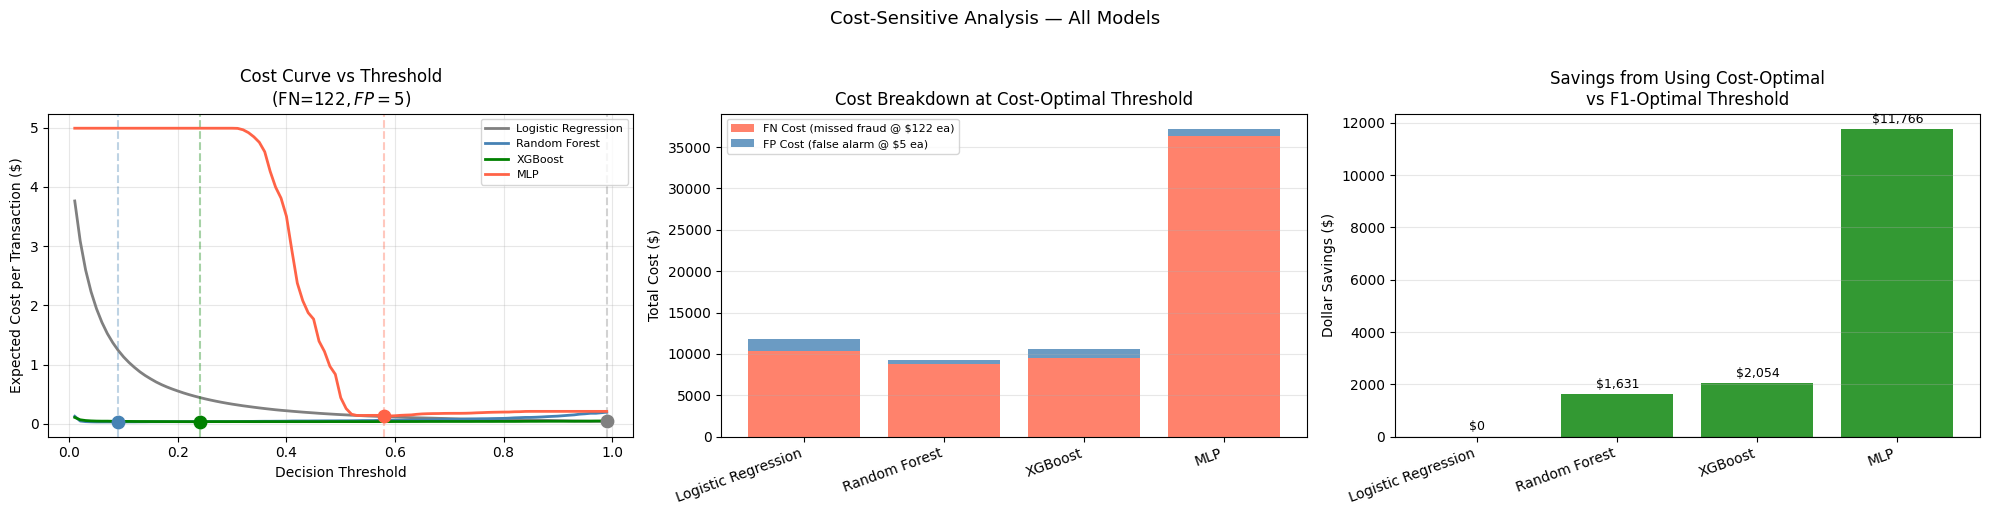

In [31]:
# ============================================================
# B-4 Cost Visualisations
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Plot 1: Cost-per-transaction vs threshold ---
ax = axes[0]
for name, curve in cost_curves.items():
    ts = [c[0] for c in curve]
    cs = [c[1] for c in curve]
    best_t = ts[int(np.argmin(cs))]
    best_c = min(cs)
    ax.plot(ts, cs, label=name, color=colors_map[name], linewidth=2)
    ax.scatter([best_t], [best_c], color=colors_map[name], s=80, zorder=5)
    ax.axvline(best_t, color=colors_map[name], linestyle='--', alpha=0.35)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Expected Cost per Transaction ($)')
ax.set_title(f'Cost Curve vs Threshold\n(FN=${FN_COST:.0f}, FP=${FP_COST:.0f})')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Plot 2: FN vs FP cost breakdown (stacked bar) at cost-optimal threshold ---
ax = axes[1]
models_list = [r['Model'] for r in cost_rows]
fn_costs    = [float(r['FN Cost ($)'].replace('$','').replace(',','')) for r in cost_rows]
fp_costs    = [float(r['FP Cost ($)'].replace('$','').replace(',','')) for r in cost_rows]
x = np.arange(len(models_list))
ax.bar(x, fn_costs, label=f'FN Cost (missed fraud @ ${FN_COST:.0f} ea)', color='tomato',    alpha=0.8)
ax.bar(x, fp_costs, bottom=fn_costs, label=f'FP Cost (false alarm @ ${FP_COST:.0f} ea)',
       color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20, ha='right')
ax.set_ylabel('Total Cost ($)')
ax.set_title('Cost Breakdown at Cost-Optimal Threshold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

# --- Plot 3: F1-threshold cost vs cost-optimal cost (savings comparison) ---
ax = axes[2]
f1_totals   = [float(r['Total Cost ($)'].replace('$','').replace(',','')) for r in f1_rows]
cost_totals = [float(r['Total Cost ($)'].replace('$','').replace(',','')) for r in cost_rows]
savings     = [f - c for f, c in zip(f1_totals, cost_totals)]
bar_colors  = ['green' if s >= 0 else 'tomato' for s in savings]
ax.bar(x, savings, color=bar_colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20, ha='right')
ax.set_ylabel('Dollar Savings ($)')
ax.set_title('Savings from Using Cost-Optimal\nvs F1-Optimal Threshold')
ax.grid(alpha=0.3, axis='y')
for i, (s, bar) in enumerate(zip(savings, ax.patches)):
    ax.text(i, s + (max(savings)*0.02 if s >= 0 else min(savings)*0.02),
            f'${s:,.0f}', ha='center', fontsize=9)

plt.suptitle('Cost-Sensitive Analysis — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ============================================================
# B-5 Key Cost Insights
# ============================================================
print("=" * 70)
print("COST-SENSITIVE ANALYSIS — KEY FINDINGS")
print("=" * 70)

# Find best model by cost-per-transaction at cost-optimal threshold
best_cost_model = min(cost_rows, key=lambda r: float(r['Cost / Txn ($)'].replace('$','')))
worst_cost_model = max(cost_rows, key=lambda r: float(r['Cost / Txn ($)'].replace('$','')))

best_cost_val  = float(best_cost_model['Cost / Txn ($)'].replace('$',''))
worst_cost_val = float(worst_cost_model['Cost / Txn ($)'].replace('$',''))

print(f"\n1. Best model (lowest cost/txn): {best_cost_model['Model']}")
print(f"   Cost-optimal threshold: {best_cost_model['Cost-Opt Thresh']}")
print(f"   Expected cost/transaction: {best_cost_model['Cost / Txn ($)']}")

print(f"\n2. Worst model (highest cost/txn): {worst_cost_model['Model']}")
print(f"   Cost-optimal threshold: {worst_cost_model['Cost-Opt Thresh']}")
print(f"   Expected cost/transaction: {worst_cost_model['Cost / Txn ($)']}")

total_txns = len(np.array(rf_all_true))
annual_txns_estimate = total_txns  # dataset covers ~2 days

print(f"\n3. Threshold shift insight:")
for i, (f1r, costr) in enumerate(zip(f1_rows, cost_rows)):
    f1_t    = float(f1r['F1-Threshold'])
    cost_t  = float(costr['Cost-Opt Thresh'])
    f1_tot  = float(f1r['Total Cost ($)'].replace('$','').replace(',',''))
    cost_tot = float(costr['Total Cost ($)'].replace('$','').replace(',',''))
    saving   = f1_tot - cost_tot
    print(f"   {f1r['Model']:22s}: F1-thresh={f1_t:.3f} → cost-thresh={cost_t:.3f}  "
          f"| savings=${saving:>8,.0f}  ({'more aggressive' if cost_t < f1_t else 'less aggressive'} flagging)")

COST-SENSITIVE ANALYSIS — KEY FINDINGS

1. Best model (lowest cost/txn): Random Forest
   Cost-optimal threshold: 0.090
   Expected cost/transaction: $0.0326

2. Worst model (highest cost/txn): MLP
   Cost-optimal threshold: 0.580
   Expected cost/transaction: $0.1306

3. Threshold shift insight:
   Logistic Regression   : F1-thresh=0.990 → cost-thresh=0.990  | savings=$       0  (less aggressive flagging)
   Random Forest         : F1-thresh=0.264 → cost-thresh=0.090  | savings=$   1,631  (more aggressive flagging)
   XGBoost               : F1-thresh=0.914 → cost-thresh=0.240  | savings=$   2,054  (more aggressive flagging)
   MLP                   : F1-thresh=0.518 → cost-thresh=0.580  | savings=$  11,766  (less aggressive flagging)


In [33]:
# ============================================================
# Final Head-to-Head: CI + Cost Combined Summary
# ============================================================
print("=" * 85)
print("FINAL SUMMARY — CI-AUGMENTED METRICS + COST (cost-optimal threshold)")
print("=" * 85)

final_rows = []
for i, (name, ci_dict) in enumerate([
    ('Logistic Regression', lr_ci),
    ('Random Forest',       rf_ci),
    ('XGBoost',             xgb_ci),
    ('MLP',                 mlp_fold_ci),
]):
    row = {'Model': name}
    for m in ['AUPRC','F1']:
        mean, lo, hi = ci_dict[m]
        row[f'{m} [95% CI]'] = f"{mean:.4f} [{lo:.4f},{hi:.4f}]"
    row['Cost/Txn (cost-opt $)'] = cost_rows[i]['Cost / Txn ($)']
    row['Cost/Txn (F1-opt $)']   = f1_rows[i]['Cost / Txn ($)']
    final_rows.append(row)

print(pd.DataFrame(final_rows).to_string(index=False))

print(f"""
Statistical significance (McNemar, MLP vs RF):
  chi-squared = {result.statistic:.4f}, p = {result.pvalue:.6f}
  {'Significant at alpha=0.05' if result.pvalue < 0.05 else 'NOT significant at alpha=0.05 — error patterns are statistically indistinguishable'}
""")

FINAL SUMMARY — CI-AUGMENTED METRICS + COST (cost-optimal threshold)
              Model         AUPRC [95% CI]             F1 [95% CI] Cost/Txn (cost-opt $) Cost/Txn (F1-opt $)
Logistic Regression 0.7248 [0.6783,0.7683]  0.6853 [0.6540,0.7155]               $0.0415             $0.0415
      Random Forest 0.8444 [0.8123,0.8747]  0.8685 [0.8447,0.8908]               $0.0326             $0.0384
            XGBoost 0.8329 [0.8005,0.8637]  0.8493 [0.8237,0.8734]               $0.0372             $0.0444
                MLP 0.4927 [0.2984,0.6870] 0.1511 [-0.0996,0.4019]               $0.1306             $0.1719

Statistical significance (McNemar, MLP vs RF):
  chi-squared = 5047.1647, p = 0.000000
  Significant at alpha=0.05



In [34]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Risk 1: Cross-Validation (AUPRC Variance)
# ============================================================

def cv_auprc(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Ensure X_train and X_val are scaled if the models expect scaled data
        # For simplicity, if models were previously fitted on scaled data,
        # we should ensure consistent scaling here or reset the expectation
        # For now, assuming the models can handle unscaled data or scale internally
        # based on how they were originally defined. If RobustScaler was crucial,
        # it would need to be re-applied within this function's loop.

        model.fit(X_train, y_train)
        probs = model.predict_proba(X_val)[:, 1]

        score = average_precision_score(y_val, probs)
        scores.append(score)

    return np.mean(scores), np.std(scores)

start = time.time()

# Instantiate the models with the same parameters as used previously
# (from cells Vx4YOYVIPUDO for LR and VBOuk_qBPP2o for RF)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
lr_model = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)

rf_mean, rf_std = cv_auprc(rf_model, X, y)
lr_mean, lr_std = cv_auprc(lr_model, X, y)

end = time.time()

print("\n--- Cross Validation Results ---")
print(f"RF AUPRC: {rf_mean:.4f} \u00b1 {rf_std:.4f}")
print(f"LR AUPRC: {lr_mean:.4f} \u00b1 {lr_std:.4f}")
print(f"Runtime: {end - start:.2f} seconds")



--- Cross Validation Results ---
RF AUPRC: 0.8476 ± 0.0261
LR AUPRC: 0.7261 ± 0.0228
Runtime: 1162.75 seconds


In [37]:
# ============================================================
# Risk 1 (continued): Bootstrap Confidence Intervals
# ============================================================

def bootstrap_ci(y_true, y_probs, n_bootstrap=1000):
    scores = []
    n = len(y_true)

    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)

        if len(np.unique(y_true[idx])) < 2:
            continue

        score = average_precision_score(y_true[idx], y_probs[idx])
        scores.append(score)

    mean = np.mean(scores)
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return mean, lower, upper

rf_probs_arr = np.array(rf_all_probs)
rf_true_arr  = np.array(rf_all_true)

mean, low, high = bootstrap_ci(rf_true_arr, rf_probs_arr)

print("\n--- Bootstrap CI ---")
print(f"RF AUPRC: {mean:.4f} (95% CI: [{low:.4f}, {high:.4f}])")


--- Bootstrap CI ---
RF AUPRC: 0.8452 (95% CI: [0.8127, 0.8769])


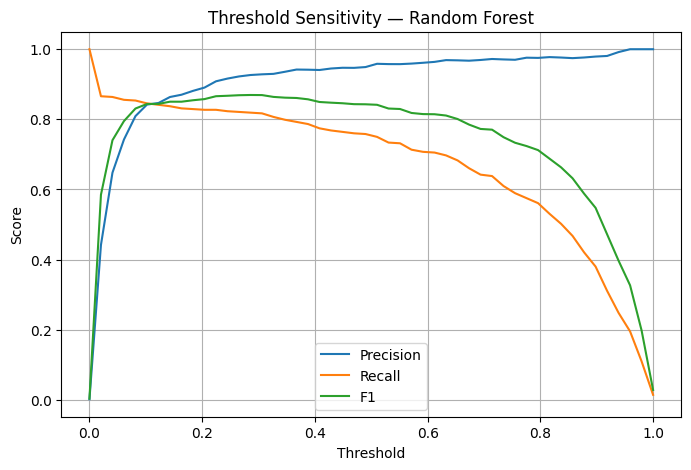

In [38]:
# ============================================================
# Risk 2: Threshold Sweep
# ============================================================

thresholds = np.linspace(0, 1, 50)

precision_list, recall_list, f1_list = [], [], []

for t in thresholds:
    preds = (rf_probs_arr >= t).astype(int)

    precision_list.append(precision_score(rf_true_arr, preds))
    recall_list.append(recall_score(rf_true_arr, preds))
    f1_list.append(f1_score(rf_true_arr, preds))

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision_list, label='Precision')
plt.plot(thresholds, recall_list, label='Recall')
plt.plot(thresholds, f1_list, label='F1')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Sensitivity — Random Forest")
plt.legend()
plt.grid()
plt.show()

In [39]:
# ============================================================
# Risk 3: Cost-Sensitive Analysis — All Models
# ============================================================

def compute_cost(y_true, y_probs, threshold=0.5, cost_fn=122, cost_fp=5):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    preds = (y_probs >= threshold).astype(int)

    total_cost = 0
    for yt, yp in zip(y_true, preds):
        if yt == 1 and yp == 0:
            total_cost += cost_fn
        elif yt == 0 and yp == 1:
            total_cost += cost_fp

    return total_cost / len(y_true)

cost_results = {
    "Logistic Regression": compute_cost(lr_all_true, lr_all_probs, threshold=lr_df["Threshold"].mean()),
    "Random Forest": compute_cost(rf_all_true, rf_all_probs, threshold=rf_df["Threshold"].mean()),
    "XGBoost": compute_cost(xgb_all_true, xgb_all_probs, threshold=xgb_df["Threshold"].mean()),
    "MLP": compute_cost(mlp_all_true, mlp_all_probs, threshold=mlp_df["Threshold"].mean()),
}

print("\n--- Cost Analysis — All Models ---")
for model, cost in cost_results.items():
    print(f"{model}: Cost per transaction = ${cost:.4f}")


--- Cost Analysis — All Models ---
Logistic Regression: Cost per transaction = $0.0415
Random Forest: Cost per transaction = $0.0383
XGBoost: Cost per transaction = $0.0443
MLP: Cost per transaction = $0.1718
